In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

In [40]:
df = pd.read_csv('data/houses_cleaned.csv')
df.shape

(3604, 19)

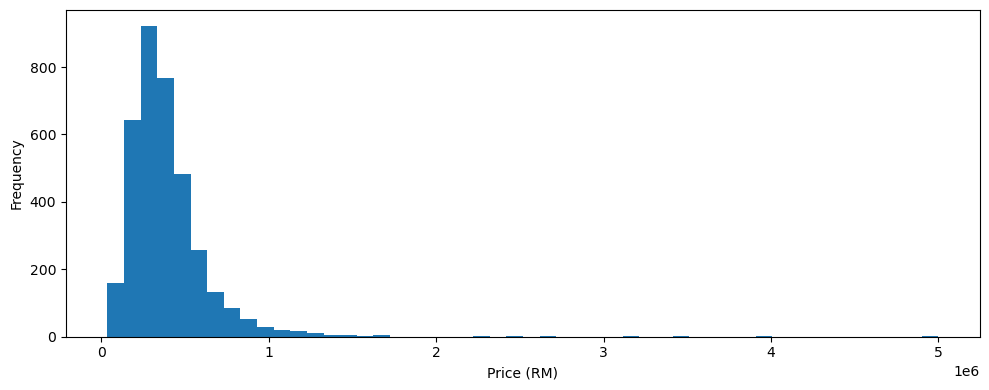

In [41]:
df['price'].plot(kind='hist', bins=50, figsize=(10, 4))
plt.xlabel('Price (RM)')
plt.tight_layout()

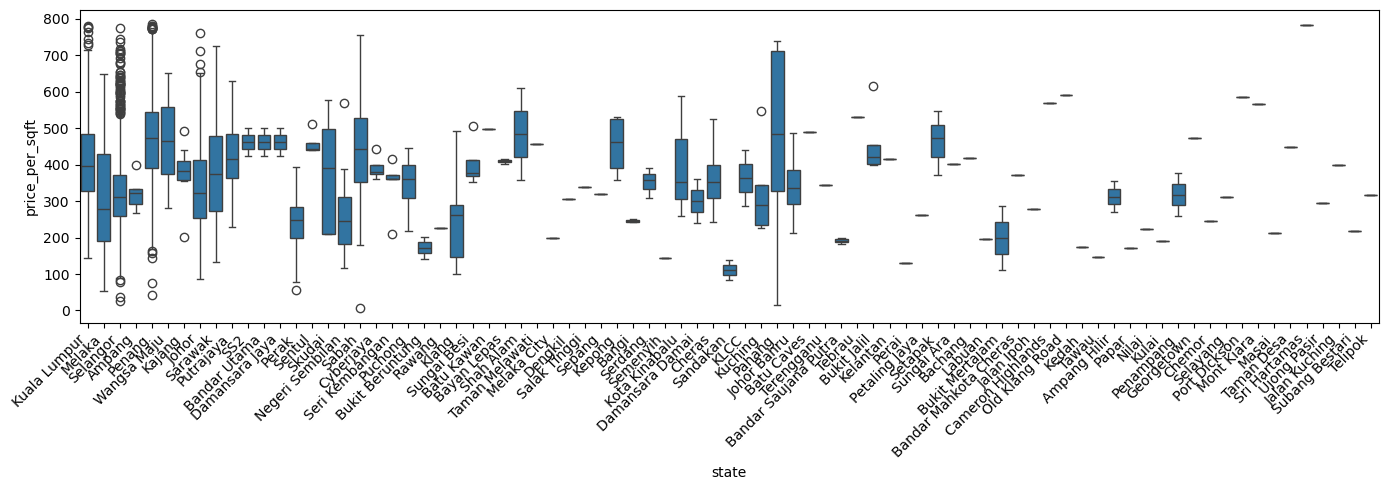

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x='state', y='price_per_sqft', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

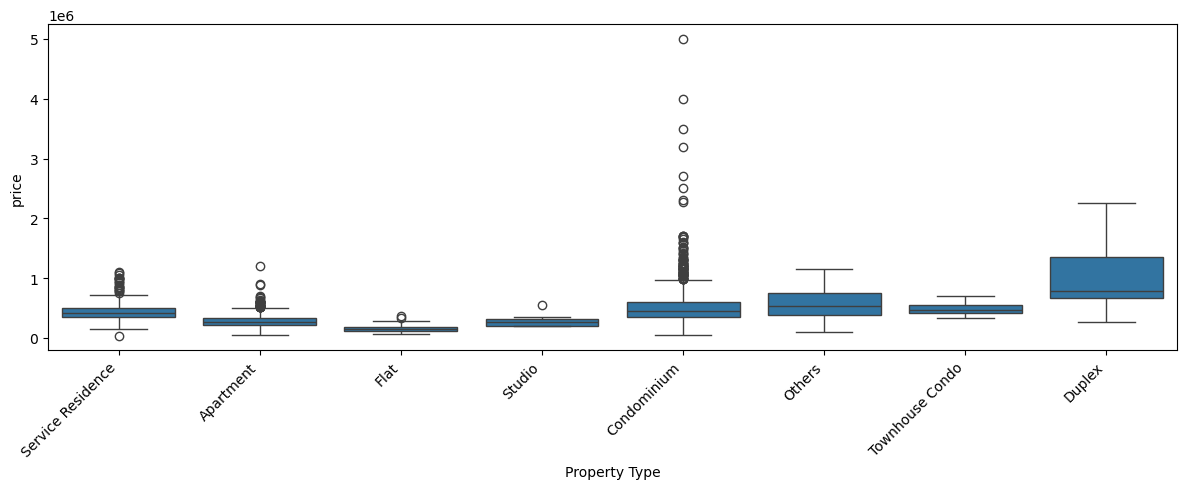

In [43]:
top_types = df['Property Type'].value_counts().head(8).index
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[df['Property Type'].isin(top_types)], x='Property Type', y='price', ax=ax)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

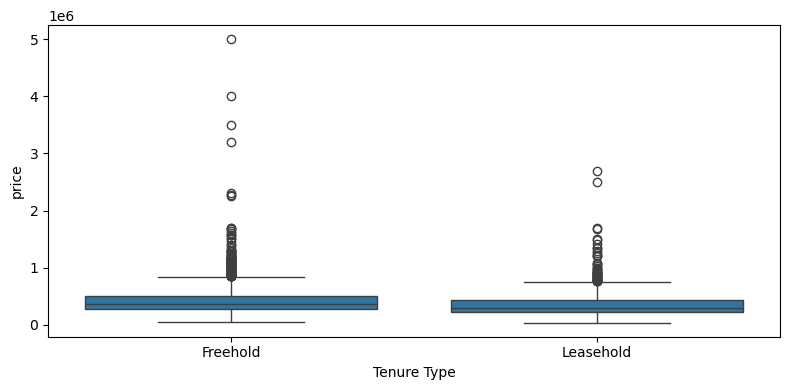

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='Tenure Type', y='price', ax=ax)
plt.tight_layout()

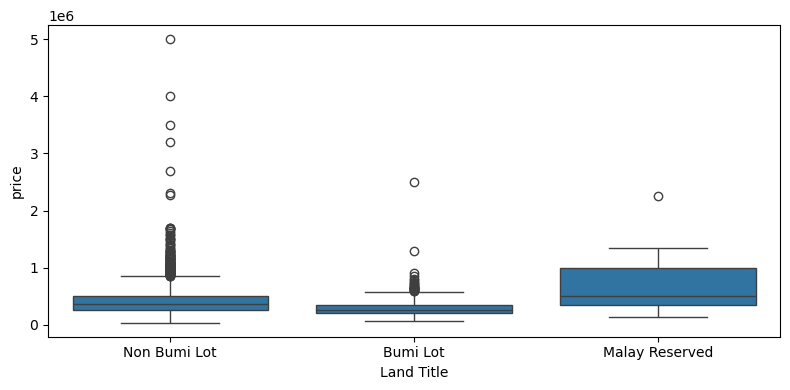

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='Land Title', y='price', ax=ax)
plt.tight_layout()

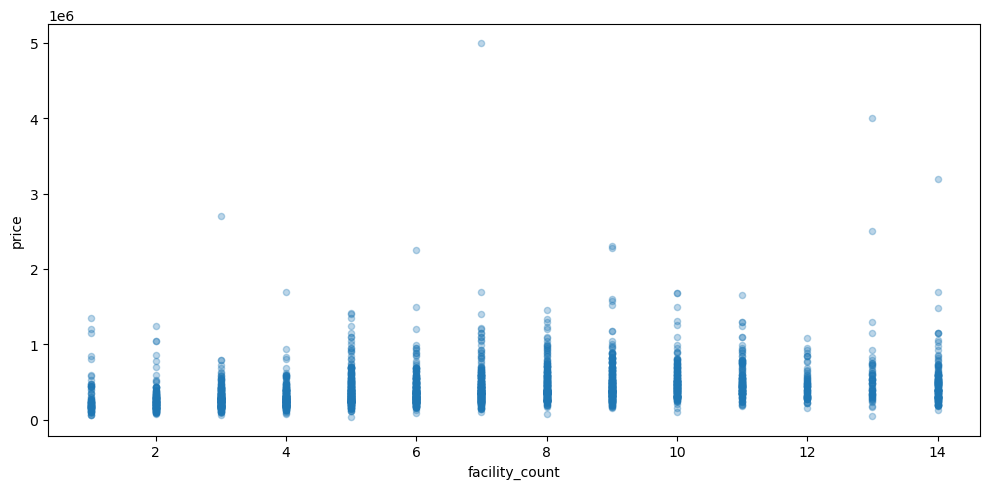

In [46]:
df.plot.scatter(x='facility_count', y='price', alpha=0.3, figsize=(10, 5))
plt.tight_layout()

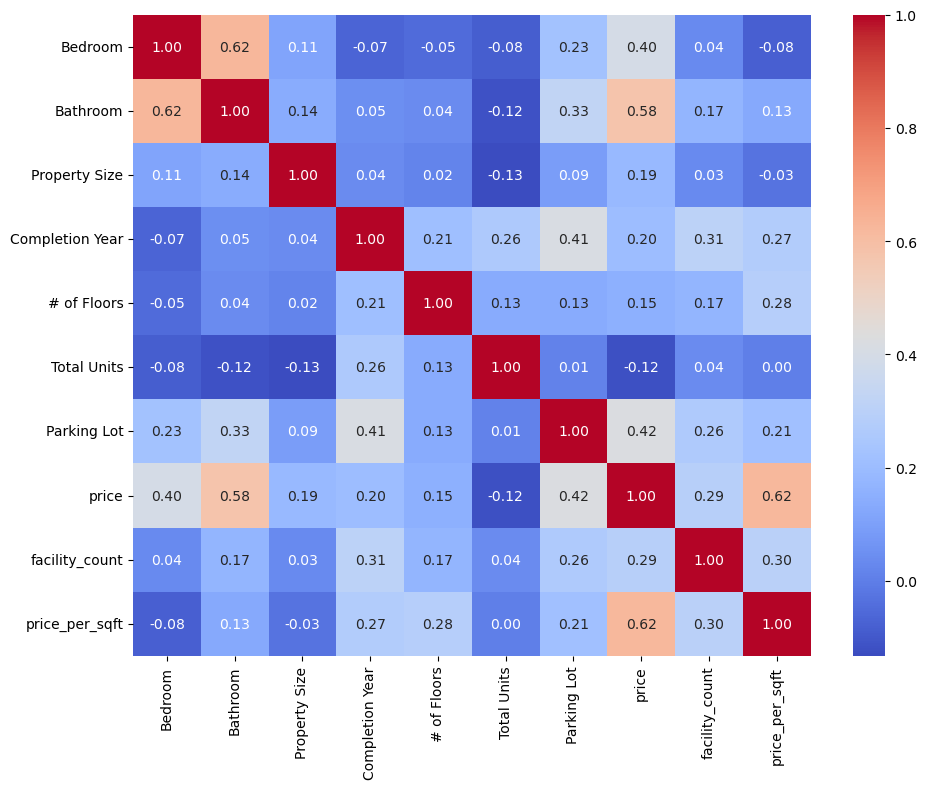

In [47]:
numeric_cols = df.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()

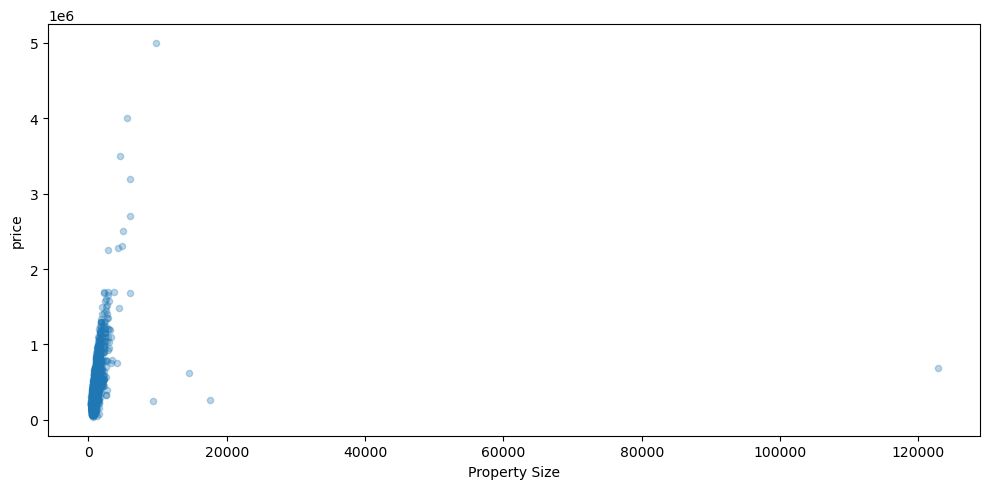

In [48]:
df.plot.scatter(x='Property Size', y='price', alpha=0.3, figsize=(10, 5))
plt.tight_layout()

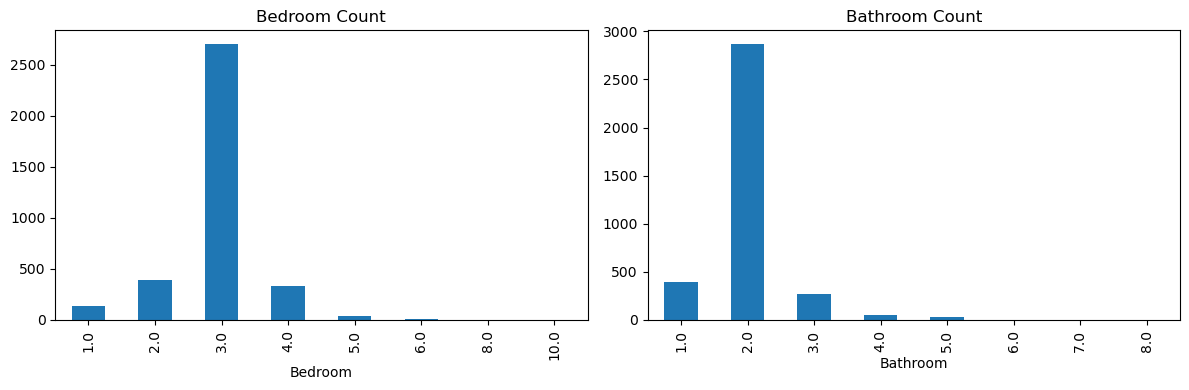

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Bedroom'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Bedroom Count')
df['Bathroom'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Bathroom Count')
plt.tight_layout()

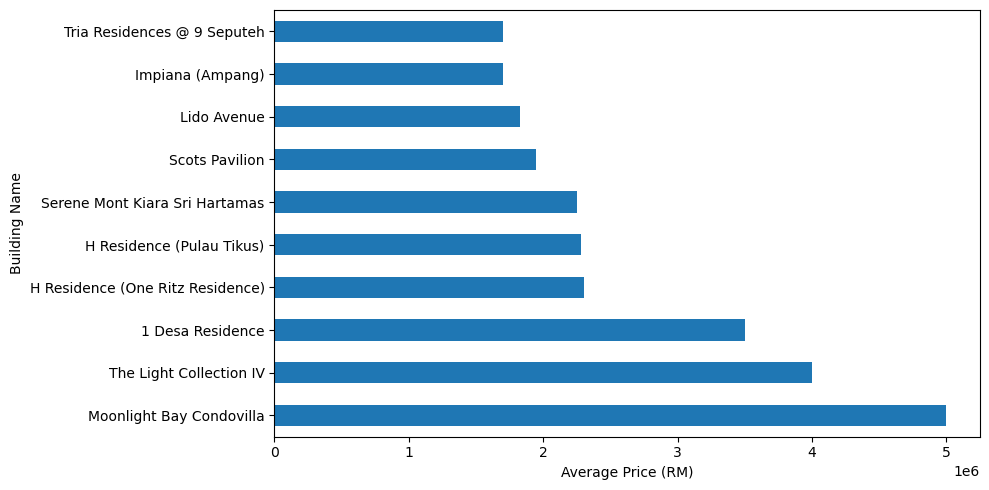

In [50]:
df.groupby('Building Name')['price'].mean().nlargest(10).plot(kind='barh', figsize=(10, 5))
plt.xlabel('Average Price (RM)')
plt.tight_layout()

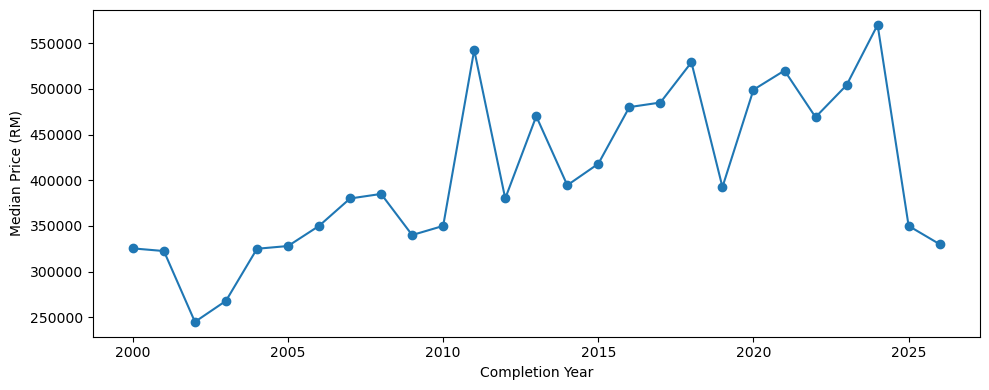

In [51]:
yearly = df.groupby('Completion Year')['price'].median().dropna()
yearly = yearly[yearly.index >= 2000]
yearly.plot(figsize=(10, 4), marker='o')
plt.ylabel('Median Price (RM)')
plt.tight_layout()

In [52]:
features = ['Property Size', 'Bedroom', 'Bathroom', 'facility_count',
            'Property Type', 'Tenure Type', 'Land Title', 'state']
target = 'price'

model_df = df[features + [target]].dropna()
X = pd.get_dummies(model_df[features], drop_first=True)
y = model_df[target]
X.shape

(2967, 79)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((2373, 79), (594, 79))

In [54]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    trained[name] = model
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

pd.DataFrame(results)

/opt/homebrew/anaconda3/envs/unifier/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/anaconda3/envs/unifier/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/anaconda3/envs/unifier/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model,MAE,RMSE,R2
0,Linear Regression,120825.659374,689022.770898,-7.816456
1,Random Forest,69941.006805,114150.567920,0.758018
2,XGBoost,73262.046875,136478.645714,0.654095


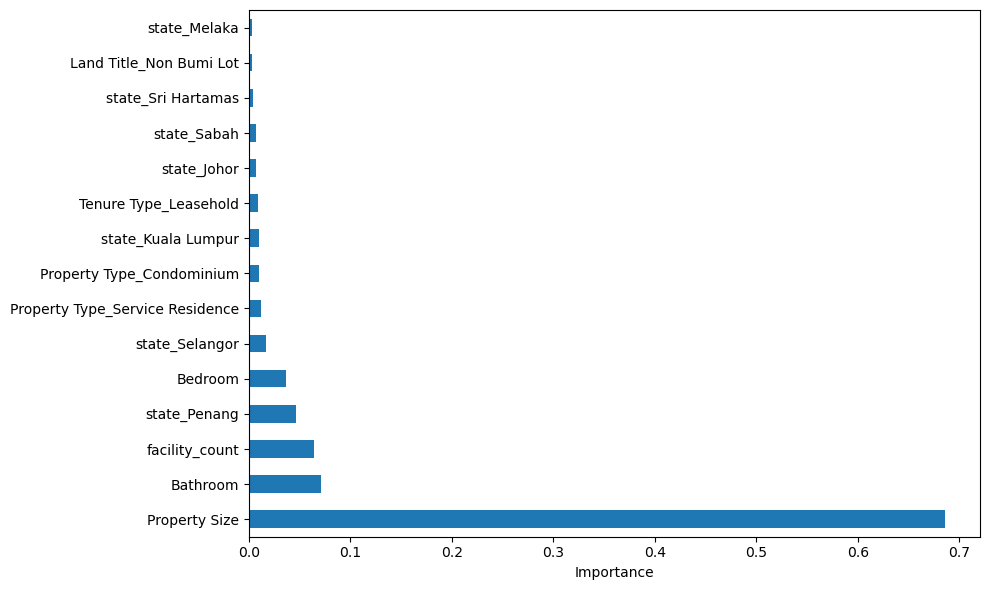

In [55]:
best_name = pd.DataFrame(results).sort_values('R2', ascending=False).iloc[0]['Model']
best_model = trained[best_name]

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
else:
    imp = pd.Series(np.abs(best_model.coef_), index=X_train.columns)

imp.nlargest(15).plot(kind='barh', figsize=(10, 6))
plt.xlabel('Importance')
plt.tight_layout()

In [56]:
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/model.pkl')
joblib.dump(list(X_train.columns), 'model/feature_columns.pkl')

['model/feature_columns.pkl']